<a href="https://www.kaggle.com/code/pavankumar960/farm-production-analysis?scriptVersionId=237574883" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Data Collection

In [2]:
# Loading Dataset
df = pd.read_csv("/kaggle/input/farm-produce-data-80-years/farm_production_dataset.csv")

In [3]:
display(df.columns)

Index(['REF_DATE', 'GEO', 'Type of crop',
       'Average farm price (dollars per tonne)',
       'Average yield (kilograms per hectare)', 'Production (metric tonnes)',
       'Seeded area (acres)', 'Seeded area (hectares)',
       'Total farm value (dollars)'],
      dtype='object')

**Observation**

 Based on Available Columns, the formulas below will determine the relation between each column, filling the missing values and cross-check the values.
   * Production per hectare = Production (tonnes) / Seeded Area (hectares)
   * Production per Acre    = Production (tonnes) / Seeded Area (Acres)
   * Yield Check            = Production (tonnes) x 1000 / Seeded Area (hectares)
   * Total Farm Value       = Production (tonnes) x Average Price
   * Revenue Per Hectare    = Total Farm Value / Seeded Area (hectares)
   * Area Conversion        : Seeded Area (acres) x 0.404686 = Seeded Hectares
   

# EDA

In [4]:
print("Dataset Shape: ")
print(df.shape)
print("\nDataSet")
display(df.head())
display(df.tail())
print('\nData Types:\n\n',df.dtypes)

Dataset Shape: 
(10273, 9)

DataSet


,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
0,1908,AB,Barley,15.00,1585.0,84000.0,129800.0,53000.0,1296
1,1908,AB,Flaxseed,29.00,950.0,1900.0,5900.0,2000.0,56
2,1908,AB,Oats,18.00,1675.0,352000.0,519400.0,210000.0,6316
3,1908,AB,"Rye, all",23.00,1665.0,5000.0,6500.0,3000.0,117
4,1908,AB,Sugar beets,0.55,18100.0,38100.0,5200.0,2100.0,208


,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
10268,1984,SK,Tame hay,78.0,2870.0,2087000.0,1800000.0,728000.0,162786
10269,1984,SK,"Wheat, all",176.0,1420.0,11485000.0,20000000.0,8094000.0,2026204
10270,1984,SK,"Wheat, durum",188.0,1200.0,1633000.0,3350000.0,1356000.0,307004
10271,1984,SK,"Wheat, spring",175.0,1460.0,9607000.0,16300000.0,6596000.0,1681225
10272,1984,SK,"Wheat, winter remaining",155.0,1730.0,245000.0,NaN,NaN,37975



Data Types:

 REF_DATE                                    int64
GEO                                        object
Type of crop                               object
Average farm price (dollars per tonne)    float64
Average yield (kilograms per hectare)     float64
Production (metric tonnes)                float64
Seeded area (acres)                       float64
Seeded area (hectares)                    float64
Total farm value (dollars)                  int64
dtype: object


In [5]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10273 entries, 0 to 10272
Data columns (total 9 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   REF_DATE                                10273 non-null  int64  
 1   GEO                                     10273 non-null  object 
 2   Type of crop                            10272 non-null  object 
 3   Average farm price (dollars per tonne)  10243 non-null  float64
 4   Average yield (kilograms per hectare)   10246 non-null  float64
 5   Production (metric tonnes)              10245 non-null  float64
 6   Seeded area (acres)                     9873 non-null   float64
 7   Seeded area (hectares)                  9847 non-null   float64
 8   Total farm value (dollars)              10273 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 722.4+ KB


None

,REF_DATE,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
count,10273.000000,10243.000000,10246.000000,1.024500e+04,9.873000e+03,9.847000e+03,1.027300e+04
mean,1947.661053,59.633078,3647.442319,1.010887e+06,1.310067e+06,5.316231e+05,5.490084e+04
std,22.204519,90.920549,8068.854966,3.044681e+06,4.881387e+06,1.978043e+06,2.502413e+05
min,1908.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1929.000000,21.000000,1055.000000,8.300000e+03,1.050000e+04,4.350000e+03,3.690000e+02
50%,1948.000000,43.000000,1485.000000,7.195000e+04,8.300000e+04,3.400000e+04,3.006000e+03
75%,1967.000000,76.000000,2363.750000,5.480000e+05,5.831000e+05,2.389000e+05,1.954100e+04
max,1984.000000,6663.300000,460305.000000,1.336790e+08,3.172035e+08,1.283890e+08,4.654194e+06


In [6]:
print("Unique Values:\n","-"*50,"\n",df.apply(lambda col: col.nunique()))
print("\nType of Crops:\n","-"*65,"\n",df['Type of crop'].unique())
print("\nGEO Location in Canada:\n","-"*72,"\n",df['GEO'].unique())

Unique Values:
 -------------------------------------------------- 
 REF_DATE                                    76
GEO                                         14
Type of crop                                23
Average farm price (dollars per tonne)     829
Average yield (kilograms per hectare)     1510
Production (metric tonnes)                4697
Seeded area (acres)                       4286
Seeded area (hectares)                    3424
Total farm value (dollars)                6576
dtype: int64

Type of Crops:
 ----------------------------------------------------------------- 
 ['Barley' 'Flaxseed' 'Oats' 'Rye, all' 'Sugar beets' 'Tame hay'
 'Wheat, all' 'Beans, all dry (white and coloured)' 'Buckwheat'
 'Corn for grain' 'Corn for silage' 'Mixed grains' 'Peas, dry'
 'Wheat, spring' 'Wheat, winter remaining' 'Rye, fall remaining'
 'Rye, spring' 'Soybeans' 'Sunflower seed' 'Canola (rapeseed)'
 'Mustard seed' nan 'Wheat, durum' 'Lentils']

GEO Location in Canada:
 -------------------

Observation
* Number of Crops is 23
* Total Geo locations is 14

# Data Cleaning

In [7]:
null_values = df.isnull().sum()

print('Null Values:\n','-'*50,'\n',null_values)
print('\nNull Values in Percentage:\n','-'*50,'\n',(null_values / len(df) * 100).round(2))

Null Values:
 -------------------------------------------------- 
 REF_DATE                                    0
GEO                                         0
Type of crop                                1
Average farm price (dollars per tonne)     30
Average yield (kilograms per hectare)      27
Production (metric tonnes)                 28
Seeded area (acres)                       400
Seeded area (hectares)                    426
Total farm value (dollars)                  0
dtype: int64

Null Values in Percentage:
 -------------------------------------------------- 
 REF_DATE                                  0.00
GEO                                       0.00
Type of crop                              0.01
Average farm price (dollars per tonne)    0.29
Average yield (kilograms per hectare)     0.26
Production (metric tonnes)                0.27
Seeded area (acres)                       3.89
Seeded area (hectares)                    4.15
Total farm value (dollars)                0.00
d

Null values exist within 5%-10%, so we can impute or drop them.

# Data Manipulation

In [22]:
#Adding new Columns so it can help with imputing nulls and more detailed analysis

df_updated = df.assign(
    prod_per_hectare       = lambda d: d["Production (metric tonnes)"]           / d["Seeded area (hectares)"],
    prod_per_acre           = lambda d: d["Production (metric tonnes)"]           / d["Seeded area (acres)"],
    yield_check             = lambda d: d["Production (metric tonnes)"] * 1000    / d["Seeded area (hectares)"],
    total_farm_value_calc   = lambda d: d["Production (metric tonnes)"]           * d["Average farm price (dollars per tonne)"],
    revenue_per_hectare     = lambda d: d["total_farm_value_calc"]                / d["Seeded area (hectares)"],
    seeded_hectares_conv    = lambda d: d["Seeded area (acres)"]                  * 0.404686
)

In [13]:
#checking for nulls again

null_values = df_updated.isnull().sum()

print('Null Values:\n','-'*50,'\n',null_values)
print('\nNull Values in Percentage:\n','-'*50,'\n',(null_values / len(df) * 100).round(2))

Null Values:
 -------------------------------------------------- 
 REF_DATE                                    0
GEO                                         0
Type of crop                                1
Average farm price (dollars per tonne)     30
Average yield (kilograms per hectare)      27
Production (metric tonnes)                 28
Seeded area (acres)                       400
Seeded area (hectares)                    426
Total farm value (dollars)                  0
prod_per_hectare                          761
prod_per_acre                             761
yield_check                               761
total_farm_value_calc                      30
revenue_per_hectare                       762
seeded_hectares_conv                      400
dtype: int64

Null Values in Percentage:
 -------------------------------------------------- 
 REF_DATE                                  0.00
GEO                                       0.00
Type of crop                              0.01
Average

In [14]:
# filling nulls by comparing both conversion

df_updated = df_updated.assign(
    seeded_hectares = lambda d: d["Seeded area (hectares)"].fillna(d["Seeded area (acres)"] * 0.404686),
    seeded_acres    = lambda d: d["Seeded area (acres)"].fillna(d["Seeded area (hectares)"] / 0.404686),
)

In [16]:
#filling nulls with mean values based on crop type

df_updated = df_updated.assign(
    avg_price = lambda d: d.groupby("Type of crop")["Average farm price (dollars per tonne)"]
                             .transform(lambda s: s.fillna(s.mean())),
    avg_yield = lambda d: d.groupby("Type of crop")["Average yield (kilograms per hectare)"]
                             .transform(lambda s: s.fillna(s.mean()))
)

In [17]:
# recalculating the formulas based on changes.

df_updated = df_updated.assign(
    prod_per_hectare       = lambda d: d["Production (metric tonnes)"]    / d["seeded_hectares"],
    prod_per_acre          = lambda d: d["Production (metric tonnes)"]    / d["seeded_acres"],
    yield_check            = lambda d: d["Production (metric tonnes)"] * 1000 / d["seeded_hectares"],
    total_farm_value_calc  = lambda d: d["Production (metric tonnes)"]    * d["avg_price"],
    revenue_per_hectare    = lambda d: d["total_farm_value_calc"]         / d["seeded_hectares"]
)

In [18]:
#dropping remaining null values

df_clean = df_updated.dropna(subset=[
    "Production (metric tonnes)",
    "seeded_hectares",
    "seeded_acres",
    "avg_price",
    "avg_yield"
])

In [19]:
#Verifying the Nulls again

print(df_clean[[
    "Production (metric tonnes)", "seeded_hectares", "seeded_acres",
    "avg_price", "avg_yield",
    "prod_per_hectare", "prod_per_acre", "yield_check",
    "total_farm_value_calc", "revenue_per_hectare"
]].isnull().sum())

Production (metric tonnes)      0
seeded_hectares                 0
seeded_acres                    0
avg_price                       0
avg_yield                       0
prod_per_hectare              335
prod_per_acre                 335
yield_check                   335
total_farm_value_calc           0
revenue_per_hectare           335
dtype: int64


In [20]:
# checking if those nulls values due to zero values in hectares and acres
print((df_clean["seeded_hectares"] == 0).sum(), "rows have 0 hectares")
print((df_clean["seeded_acres"]    == 0).sum(), "rows have 0 acres")

df_clean[df_clean["seeded_hectares"] == 0].head()


337 rows have 0 hectares
337 rows have 0 acres


,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars),prod_per_hectare,prod_per_acre,yield_check,total_farm_value_calc,revenue_per_hectare,seeded_hectares_conv,seeded_hectares,seeded_acres,avg_price,avg_yield
7,1908,BC,Barley,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
8,1908,BC,Oats,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
9,1908,BC,"Wheat, all",0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
109,1909,BC,Barley,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
110,1909,BC,Oats,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0


In [21]:
# Final Dataset by removing those zero values

df_final = (
    df_clean
      .query("seeded_hectares > 0 and seeded_acres > 0")
      .assign(
         prod_per_hectare      = lambda d: d["Production (metric tonnes)"] / d["seeded_hectares"],
         prod_per_acre          = lambda d: d["Production (metric tonnes)"] / d["seeded_acres"],
         yield_check            = lambda d: d["Production (metric tonnes)"] * 1000 / d["seeded_hectares"],
         total_farm_value_calc  = lambda d: d["Production (metric tonnes)"] * d["avg_price"],
         revenue_per_hectare    = lambda d: d["total_farm_value_calc"] / d["seeded_hectares"]
      )
)

# Checking for nulls again
print(df_final[[
    "prod_per_hectare", "prod_per_acre", "yield_check",
    "total_farm_value_calc", "revenue_per_hectare"
]].isnull().sum())


prod_per_hectare         0
prod_per_acre            0
yield_check              0
total_farm_value_calc    0
revenue_per_hectare      0
dtype: int64


In [33]:
# Checking for Duplicates
dup_count = df_final.duplicated().sum()
print(f"Total duplicate rows: {dup_count}")

Total duplicate rows: 0


In [36]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
REF_DATE,9509.0,1.947128e+03,2.229011e+01,1908.0000,1928.000000,1.948000e+03,1.967000e+03,1.984000e+03
Average farm price (dollars per tonne),9508.0,6.068462e+01,6.390857e+01,0.0000,23.000000,4.400000e+01,7.700000e+01,6.770000e+02
Average yield (kilograms per hectare),9509.0,3.818133e+03,6.892534e+03,0.0000,1100.000000,1.525000e+03,2.475000e+03,5.270000e+04
Production (metric tonnes),9509.0,1.065385e+06,2.840720e+06,0.0000,9850.000000,7.690000e+04,6.130000e+05,2.671475e+07
Seeded area (acres),9509.0,1.326857e+06,3.765518e+06,100.0000,14000.000000,9.210000e+04,6.410000e+05,3.380700e+07
Seeded area (hectares),9509.0,5.370179e+05,1.523927e+06,40.0000,5700.000000,3.730000e+04,2.590500e+05,1.368050e+07
Total farm value (dollars),9509.0,5.819748e+04,2.575263e+05,0.0000,451.000000,3.310000e+03,2.100400e+04,4.654194e+06
prod_per_hectare,9509.0,3.950866e+00,7.035715e+00,0.0000,1.109091,1.537037e+00,2.575556e+00,5.275000e+01
prod_per_acre,9509.0,1.600278e+00,2.852463e+00,0.0000,0.450427,6.219739e-01,1.041176e+00,2.293478e+01
yield_check,9509.0,3.950866e+03,7.035715e+03,0.0000,1109.090909,1.537037e+03,2.575556e+03,5.275000e+04


In [37]:
df_final = df_final.query(
    "seeded_hectares > 0 and seeded_acres > 0 and avg_price > 0 and avg_yield > 0"
)


In [39]:
# Recompute derived metrics (just to be sure)
df_final = df_final.assign(
    prod_per_hectare      = lambda d: d["Production (metric tonnes)"] / d["seeded_hectares"],
    prod_per_acre         = lambda d: d["Production (metric tonnes)"] / d["seeded_acres"],
    yield_check           = lambda d: d["Production (metric tonnes)"] * 1000 / d["seeded_hectares"],
    total_farm_value_calc = lambda d: d["Production (metric tonnes)"] * d["avg_price"],
    revenue_per_hectare   = lambda d: d["total_farm_value_calc"] / d["seeded_hectares"]
)

# Confirm no more zeros in key columns
print((df_final[[
    "seeded_hectares","avg_price","avg_yield",
    "prod_per_hectare","yield_check"
]] == 0).sum())


seeded_hectares     0
avg_price           0
avg_yield           0
prod_per_hectare    1
yield_check         1
dtype: int64


In [40]:
# 1. Drop rows where production itself is zero
df_final = df_final.query("`Production (metric tonnes)` > 0")

# 2. Recompute those two derived columns
df_final = df_final.assign(
    prod_per_hectare = lambda d: d["Production (metric tonnes)"] / d["seeded_hectares"],
    yield_check      = lambda d: d["Production (metric tonnes)"] * 1000 / d["seeded_hectares"]
)

# 3. Verify no zeros remain
print((df_final[[
    "prod_per_hectare", "yield_check"
]] == 0).sum())


prod_per_hectare    0
yield_check         0
dtype: int64


In [41]:
df_final.apply(lambda col: (col.skew() if pd.api.types.is_numeric_dtype(col) else None))


REF_DATE                                  -0.039425
GEO                                             NaN
Type of crop                                    NaN
Average farm price (dollars per tonne)     2.793243
Average yield (kilograms per hectare)      3.286263
Production (metric tonnes)                 4.610234
Seeded area (acres)                        4.686566
Seeded area (hectares)                     4.685820
Total farm value (dollars)                10.391042
prod_per_hectare                           3.166874
prod_per_acre                              3.171466
yield_check                                3.166874
total_farm_value_calc                     10.417629
revenue_per_hectare                        5.272975
seeded_hectares_conv                       4.686566
seeded_hectares                            4.685820
seeded_acres                               4.686566
avg_price                                  2.793180
avg_yield                                  3.286263
is_duplicate

In [43]:
to_log = [
    "Average farm price (dollars per tonne)",
    "Average yield (kilograms per hectare)",
    "Production (metric tonnes)",
    "Seeded area (acres)",
    "Seeded area (hectares)",
    "seeded_hectares_conv",
    "Total farm value (dollars)",
    "total_farm_value_calc",
    "revenue_per_hectare"
]

df_transformed = df_final.copy().assign(
    **{f"{col}_log": lambda d, c=col: np.log1p(d[c]) for col in to_log}
)

In [44]:
df_transformed[[f"{col}_log" for col in to_log]].apply(lambda s: s.skew())


Average farm price (dollars per tonne)_log   -1.071081
Average yield (kilograms per hectare)_log     1.363185
Production (metric tonnes)_log               -0.134798
Seeded area (acres)_log                      -0.042677
Seeded area (hectares)_log                   -0.038956
seeded_hectares_conv_log                     -0.041894
Total farm value (dollars)_log               -0.046634
total_farm_value_calc_log                    -0.072407
revenue_per_hectare_log                      -0.262823
dtype: float64

**Skewness**

* Values between –0.5 and +0.5 are generally considered quite symmetric.
* Values between ±0.5 and ±1 show mild skewness.
* Values beyond ±1 indicate stronger skew.

# Data Visualization

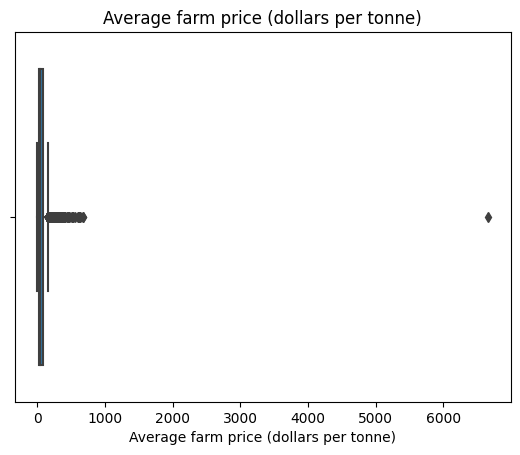

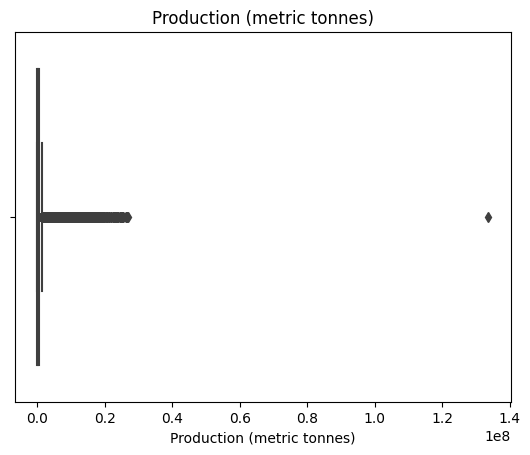

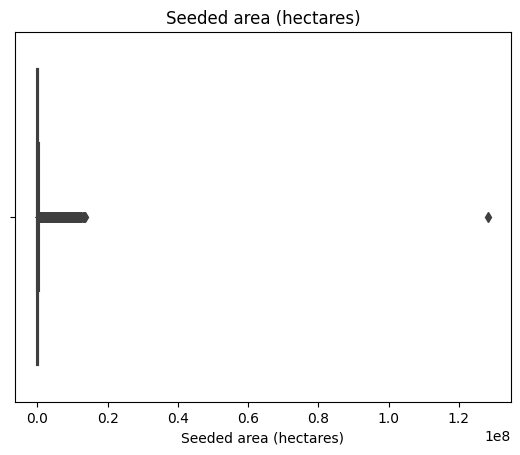

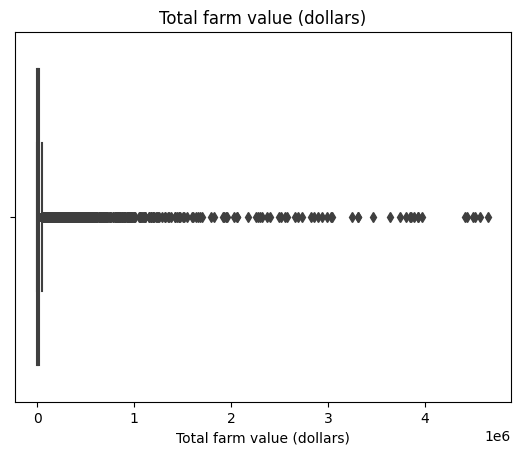

In [45]:
cols_to_plot = ['Average farm price (dollars per tonne)', 'Production (metric tonnes)', 
                'Seeded area (hectares)', 'Total farm value (dollars)']
for col in cols_to_plot:
    sns.boxplot(data=df_updated, x=col)
    plt.title(col)
    plt.show()

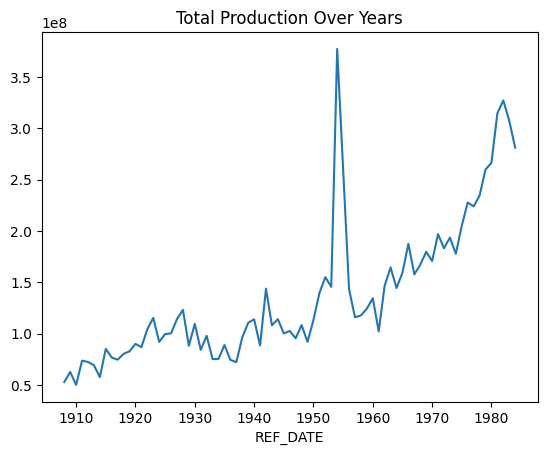

In [46]:
df_updated.groupby('REF_DATE')['Production (metric tonnes)'].sum().plot(title='Total Production Over Years')
plt.show()


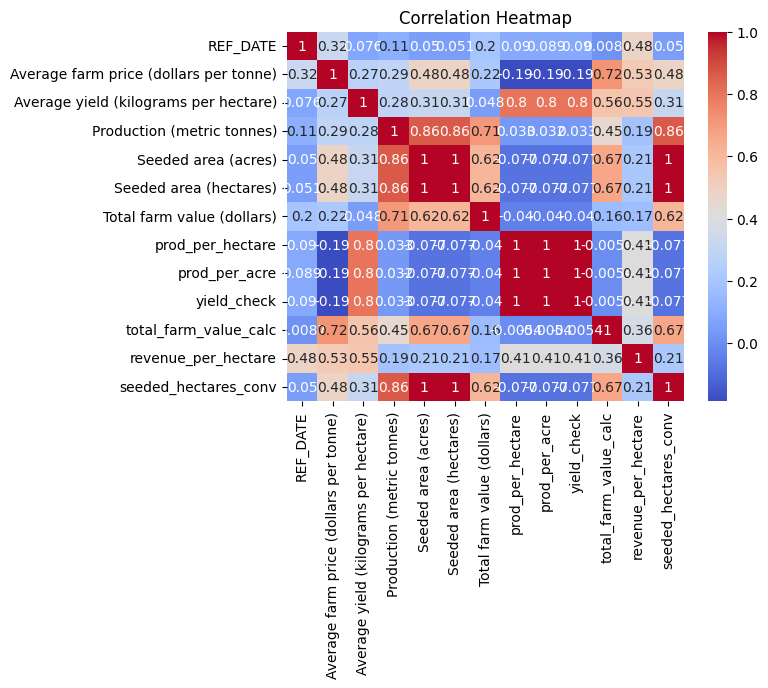

In [47]:
corr = df_updated.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
